# Evaluation of scoring functions against MatchMS implementations

Please use venv for MatchMS, which often breaks library dependency. 

In [ ]:
# Install or upgrade packages if needed
# !pip install --upgrade matchms
# !pip install --upgrade asari-metabolomics

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
# asari ver 1.17.1 or later
from asari.tools.cosine import simple_cosine, hungarian_cosine, dot_product, linear_cosine

from matchms import Spectrum
from matchms.similarity import CosineLinear, CosineHungarian, CosineGreedy

MS2_mz_tolerance = 0.01

In [3]:
# test data
expt_spectra = json.load(open('Examples_100_experimental_spectra_SD_250708_017.json', encoding='utf-8'))
db_spectra = json.load(open('Examples_100_database_spectra_cleaned.json', encoding='utf-8'))
len(expt_spectra), len(db_spectra), expt_spectra[22], db_spectra[11]

(100,
 100,
 {'spid': 'sp315',
  'precursor_mz': 178.122650146484,
  'rtime': 29.72318227005006,
  'peaks': [[73.57555389404297, 0.22057852149009705],
   [82.62570190429688, 0.23378682136535645],
   [88.02153015136719, 0.6148461699485779],
   [88.5119857788086, 0.22876766324043274],
   [89.26974487304688, 0.2281072586774826],
   [90.97099304199219, 0.21212522685527802],
   [98.8597412109375, 0.20618148148059845],
   [119.04922485351562, 1.0],
   [129.54098510742188, 0.21080438792705536],
   [133.57142639160156, 0.24541011452674866],
   [165.06753540039062, 0.21344605088233948],
   [167.35935974121094, 0.22599393129348755]]},
 {'NAME': 'L-Leucine',
  'PRECURSORMZ': '132.101905076',
  'PRECURSORTYPE': '[M+H]+',
  'IONMODE': 'Positive',
  'FORMULA': 'C6H13NO2',
  'SMILES': 'CC(C)C[C@@H](C(=O)O)N',
  'INCHIKEY': 'ROHFNLRQFUQHCH-YFKPBYRVSA-N',
  'IONIZATION': 'ESI',
  'INSTRUMENTTYPE': 'LC-ESI-QTOF',
  'COLLISIONENERGY': '20',
  'RETENTIONTIME': '0.844',
  'CCS': '132.0169887',
  'ONTOLOGY'

In [8]:
simple_cosine(expt_spectra[11]['peaks'], db_spectra[11]['peaks'], mz_tolerance=MS2_mz_tolerance)

np.float64(0.99666762748202)

In [10]:
cosine_similarity(np.array(expt_spectra[11]['peaks']), np.array(db_spectra[11]['peaks']), 
                  tolerance=MS2_mz_tolerance, penalty=0)

(0.4175487025140899, 2)

In [11]:
cosine_similarity(np.array(expt_spectra[11]['peaks']), np.array(db_spectra[11]['peaks']), 
                  tolerance=MS2_mz_tolerance, penalty=1)

(0.6438873130618797, 2)

In [29]:
peaks1, peaks2 = np.array(expt_spectra[11]['peaks']), np.array(db_spectra[11]['peaks'])

In [30]:
t = Spectrum(mz=peaks2[:, 0], intensities=peaks2[:, 1])

2026-05-21 08:28:44,353:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.


In [31]:
cosine_linear = CosineLinear.CosineLinear(tolerance=0.01)
cosine_linear.pair(t, t)

array((1., 25), dtype=[('score', '<f8'), ('matches', '<i8')])

In [ ]:
reference = Spectrum(mz=np.array([100, 150, 200.]),
                     intensities=np.array([0.7, 0.2, 0.1]),
                     metadata={"precursor_mz": 200.0})

In [4]:
def matchms_scoring(spec1, spec2, tolerance, score_class):
    cosine_function = score_class(tolerance=tolerance)
    ref_ = Spectrum(mz=np.array([x[0] for x in spec2['peaks']]),
                    intensities=np.array([x[1] for x in spec2['peaks']]),
    )
    que_ =  Spectrum(mz=np.array([x[0] for x in spec1['peaks']]),
                    intensities=np.array([x[1] for x in spec1['peaks']]),
    )
    return cosine_function.pair(ref_, que_).tolist()[0]

In [6]:
results_matchms_cosine_linear = [
    matchms_scoring(expt_spectra[ii], db_spectra[ii], MS2_mz_tolerance, CosineLinear) for ii in range(100)
]
results_matchms_cosine_hungarian = [
    matchms_scoring(expt_spectra[ii], db_spectra[ii], MS2_mz_tolerance, CosineHungarian) for ii in range(100)
]
results_matchms_cosine_greedy = [
    matchms_scoring(expt_spectra[ii], db_spectra[ii], MS2_mz_tolerance, CosineGreedy) for ii in range(100)
]

2026-05-21 09:19:53,252:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:53,253:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,608:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,609:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,609:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,609:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,609:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,610:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,610:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,610:WARNING:matchms:add_precursor_mz:No precursor_mz found in metadata.
2026-05-21 09:19:55,610:WARNING:matchms:add_precursor_mz:No precursor_mz found i

In [67]:
results_matchms_cosine_linear[:8], results_matchms_cosine_hungarian[:8], results_matchms_cosine_greedy[:8]

([0.770337932484182,
  0.9716344428246219,
  0.9851227364796197,
  0.7279047382253012,
  0.053796314605645046,
  0.9963337542361655,
  0.844639353889037,
  0.9560146279211457],
 [0.770337932484182,
  0.9716344428246223,
  0.9851227364796197,
  0.7279047382253012,
  0.05379631460564507,
  0.9963337542361655,
  0.844639353889037,
  0.9560146279211457],
 [0.770337932484182,
  0.9716344428246221,
  0.9851227364796197,
  0.7279047382253011,
  0.05379631460564505,
  0.9963337542361658,
  0.844639353889037,
  0.9560146279211457])

<Figure size 640x480 with 0 Axes>

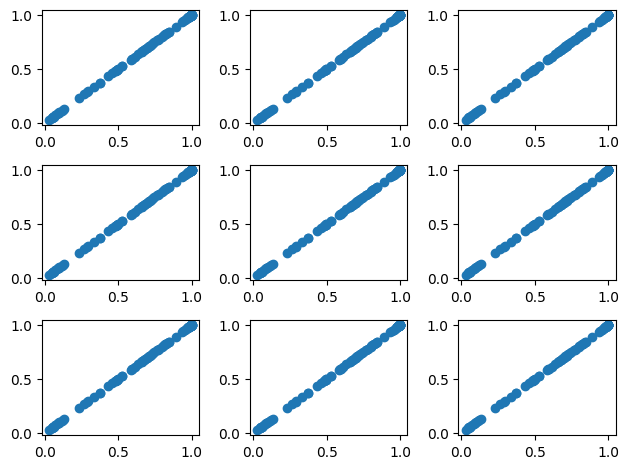

In [7]:
data = [results_matchms_cosine_linear, results_matchms_cosine_hungarian, results_matchms_cosine_greedy]
plt.figure()
fig, axes = plt.subplots(3, 3)
for ii in range(3):
    for jj in range(3):
        axes[ii, jj].scatter(data[ii], data[jj] )

plt.tight_layout()
plt.show()
plt.close()

In [10]:
results_simple_cosine = [simple_cosine(expt_spectra[ii]['peaks'], db_spectra[ii]['peaks'], 
                                       MS2_mz_tolerance) for ii in range(100)]
results_hungarian_cosine = [hungarian_cosine(expt_spectra[ii]['peaks'], db_spectra[ii]['peaks'], 
                                       MS2_mz_tolerance) for ii in range(100)]
results_linear_cosine = [linear_cosine(expt_spectra[ii]['peaks'], db_spectra[ii]['peaks'], 
                                       MS2_mz_tolerance) for ii in range(100)]
results_dot_product = [dot_product(expt_spectra[ii]['peaks'], db_spectra[ii]['peaks'], 
                                       MS2_mz_tolerance) for ii in range(100)]

In [11]:
data2 = [
    results_linear_cosine, results_hungarian_cosine, results_simple_cosine, results_dot_product
]

<Figure size 640x480 with 0 Axes>

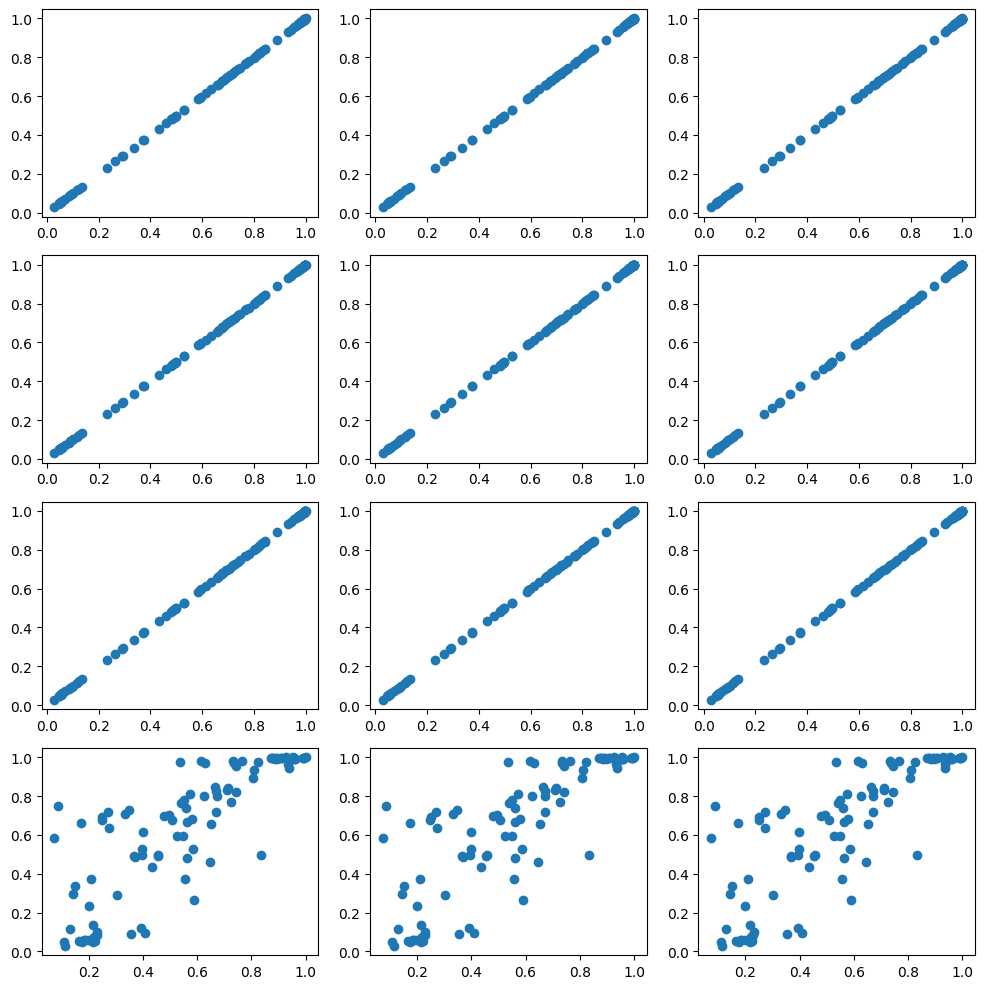

In [13]:
plt.figure()
fig, axes = plt.subplots(4, 3, figsize=(10,10))
for ii in range(4):
    for jj in range(3):
        axes[ii, jj].scatter(data2[ii], data[jj] )

plt.tight_layout()
plt.show()
plt.close()

# Conclusion

The variations of cosine similarity are largely identical, but different from dot procut. 